# 把Q2的資料聚合看看

In [4]:
import seaborn as sns
import pandas as pd

# 1. 讀取資料
file_path = 'CMP-training-removalrate.csv'
df = pd.read_csv(file_path)

# 設定繪圖風格
sns.set(style="whitegrid", font_scale=1.2)

# ==========================================
# 1. 樣本規模與變數維度
# ==========================================
print("--- 1. Data summary ---")
print(f"Sample numbers: {len(df)}")
print(f"Feature columns: {df.columns.tolist()}")
# 根據資料集說明補充：輸入變數 25 個，輸出變數 1 個
print(f"Number of input variables: 25 (Sensor variables)")
print(f"Target variable: AVG_REMOVAL_RATE")
print("-" * 30 + "\n")

# ==========================================
# 2. 目標變數統計特性
# ==========================================
print("--- 2. Target variable statistics ---")
stats = df['AVG_REMOVAL_RATE'].describe()
print(stats)
print("-" * 30 + "\n")

# ==========================================
# 3. 不同製程階段 (STAGE) 分布
# ==========================================
print("--- 3. Stage Statistics ---")
stage_stats = df.groupby('STAGE')['AVG_REMOVAL_RATE'].describe()
print(stage_stats)
print("-" * 30 + "\n")


--- 1. Data summary ---
Sample numbers: 1981
Feature columns: ['WAFER_ID', 'STAGE', 'AVG_REMOVAL_RATE']
Number of input variables: 25 (Sensor variables)
Target variable: AVG_REMOVAL_RATE
------------------------------

--- 2. Target variable statistics ---
count    1981.000000
mean       98.631645
std       187.429160
min        53.426550
25%        72.376500
50%        79.154850
75%        88.702050
max      4326.154050
Name: AVG_REMOVAL_RATE, dtype: float64
------------------------------

--- 3. Stage Statistics ---
        count        mean         std       min        25%       50%  \
STAGE                                                                  
A      1166.0  111.674864  243.378343  53.42655  71.894137  77.34585   
B       815.0   79.971039    9.150406  54.30720  73.326375  81.51060   

             75%         max  
STAGE                         
A      148.03755  4326.15405  
B       86.75595   101.46480  
------------------------------



In [5]:
import pandas as pd
import glob
import os

# ==========================================
# 1. 設定路徑 (請確認標籤檔也在這個 base_path 或修改路徑)
# ==========================================
base_path = r"C:\Users\user\OneDrive - 國立陽明交通大學\桌面\001__1142碩士生存指南\536907_製造數據科學_洪佑鑫\1142MDS_Project_313652018_Xuan-Wei-Wang\Assignment02\2016 PHM Data Challenge\2016 PHM DATA CHALLENGE CMP DATA SET\CMP-data"
training_data_path = os.path.join(base_path, "training")
label_file = os.path.join(base_path, "CMP-training-removalrate.csv")

# 獲取所有感測器 CSV 檔案
file_list = glob.glob(os.path.join(training_data_path, "*.csv"))
print(f"Find {len(file_list)} sensor files, about to aggregate...")

# ==========================================
# 2. 邊讀邊算的聚合邏輯 (節省算力/記憶體)
# ==========================================
summary_list = []

for i, file in enumerate(file_list):
    # 讀取單一晶圓感測數據
    temp_df = pd.read_csv(file)
    
    if temp_df.empty:
        print(f">>>>>> ERROR: Empty file {os.path.basename(file)}")
        continue
    try:
        # 提取 ID 資訊 (從第一筆讀取即可)
        wafer_id = str(temp_df['WAFER_ID'].iloc[0]) # 強制轉字串，避免長數字變科學記號
        stage = temp_df['STAGE'].iloc[0]
        chamber = temp_df['CHAMBER'].iloc[0]
        
        # 挑選感測器數值欄位進行計算 (剔除 ID、STAGE、CHAMBER、TIMESTAMP)
        # 這裡會保留所有 Sensor 欄位
        features_only = temp_df.drop(columns=['WAFER_ID', 'STAGE', 'CHAMBER', 'TIMESTAMP', 'MACHINE_ID', 'MACHINE_DATA'], errors='ignore')
        
        # 計算平均值 (Mean) 與 標準差 (Std)
        stats = features_only.agg(['mean', 'std'])
        
        # 將統計結果拉平 (Flatten) 變成一橫列
        # 欄位會變成：USAGE_OF_BACKING_FILM_mean, USAGE_OF_BACKING_FILM_std ...
        row_stats = stats.unstack().to_frame().T
        row_stats.columns = [f'{col[0]}_{col[1]}' for col in row_stats.columns]
        # 計算該 CSV 檔案的總行數，這代表了該 Wafer 處理的總時長 (假設 1Hz)
        row_stats['Process_Duration'] = len(temp_df)
        
        # 補回這片晶圓的身分證
        row_stats['WAFER_ID'] = wafer_id
        row_stats['STAGE'] = stage
        row_stats['CHAMBER'] = chamber
        
        summary_list.append(row_stats)
    except Exception as e:
        print(f">>>>>> ERROR: File {os.path.basename(file)} is invalid: {str(e)}")
        continue

    if (i+1) % 50 == 0:
        print(f"====== PROGRESS: Processed {i+1} files...")  
        
# 合併所有晶圓的統計特徵
df_features = pd.concat(summary_list, ignore_index=True)

# ==========================================
# 3. 讀取標籤檔並合併
# ==========================================
print("\n Aggregating labels...")
labels = pd.read_csv(label_file)

# 關鍵步驟：確保兩邊的 Key 型態完全一致
df_features['WAFER_ID'] = df_features['WAFER_ID'].astype(str)
df_features['STAGE'] = df_features['STAGE'].astype(str)
labels['WAFER_ID'] = labels['WAFER_ID'].astype(str)
labels['STAGE'] = labels['STAGE'].astype(str)

# 進行 Inner Join 合併
df_final = pd.merge(df_features, labels, on=['WAFER_ID', 'STAGE'], how='inner')

# ==========================================
# 4. 輸出結果檢查
# ==========================================
if df_final.empty:
    print(">>>>> ERROR: No matching records found after merging features and labels. Please check the keys and data integrity.")
else:
    print("===>>>>> SUCCESS: Data aggregation complete!<<<<<<===")
    print(f"Final feature matrix shape: {df_final.shape}")
    print(f"Target variable (AVG_REMOVAL_RATE) mean: {df_final['AVG_REMOVAL_RATE'].mean():.2f}")

# 顯示前五筆
df_final.head()

Find 185 sensor files, about to aggregate...
====== PROGRESS: Processed 50 files...
>>>>>> ERROR: Empty file CMP-training-066.csv
====== PROGRESS: Processed 100 files...
====== PROGRESS: Processed 150 files...

 Aggregating labels...
===>>>>> SUCCESS: Data aggregation complete!<<<<<<===
Final feature matrix shape: (184, 43)
Target variable (AVG_REMOVAL_RATE) mean: 141.84


,USAGE_OF_BACKING_FILM_mean,USAGE_OF_BACKING_FILM_std,USAGE_OF_DRESSER_mean,USAGE_OF_DRESSER_std,USAGE_OF_POLISHING_TABLE_mean,USAGE_OF_POLISHING_TABLE_std,USAGE_OF_DRESSER_TABLE_mean,USAGE_OF_DRESSER_TABLE_std,PRESSURIZED_CHAMBER_PRESSURE_mean,PRESSURIZED_CHAMBER_PRESSURE_std,...,HEAD_ROTATION_std,DRESSING_WATER_STATUS_mean,DRESSING_WATER_STATUS_std,EDGE_AIR_BAG_PRESSURE_mean,EDGE_AIR_BAG_PRESSURE_std,Process_Duration,WAFER_ID,STAGE,CHAMBER,AVG_REMOVAL_RATE
0,9338.075348,80.511031,536.057573,4.722434,251.504029,89.195353,2667.598963,3.184136,52.752363,40.698930,...,6.885360,0.542452,0.498263,30.924644,25.202157,3663,371447024,A,1.0,149.13090
1,9703.238113,86.864677,555.676669,3.804677,236.174626,77.198713,2680.840584,2.578330,58.225718,34.741006,...,7.012532,0.328698,0.469784,34.128126,22.388594,5321,-875170052,B,4.0,65.91045
2,9991.971483,96.929373,572.558344,4.283878,127.033832,84.162334,2692.247485,2.883222,57.107475,40.485907,...,6.836252,0.454467,0.497949,32.430797,24.865236,9246,371447032,A,1.0,149.99265
3,2972.610931,4537.516981,593.001318,4.288880,171.553078,91.691896,2706.046090,2.905676,54.466533,36.707887,...,7.015192,0.501942,0.500023,31.256611,23.394538,9270,329446704,A,1.0,147.94095
4,418.110632,89.717660,609.219440,4.669346,125.133370,79.775997,2716.988978,3.133999,51.863476,36.692925,...,7.005521,0.426232,0.494559,29.660509,22.800634,8120,329446870,A,1.0,147.02025


在Aggregation 過程中發現066這個training csv檔案是完全空白的。  
下面檢查：
1. 重複樣本
2. 冗餘欄位
3. 缺失值
4. 異常值

Number of duplicate rows: 0
Number of constant columns: 0
Constant columns: []
Number of missing values after merging: 0


C:\Users\user\AppData\Local\Temp\ipykernel_22300\4249928572.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='STAGE', y='AVG_REMOVAL_RATE', data=df, ax=axes[0], palette='Set2')
C:\Users\user\AppData\Local\Temp\ipykernel_22300\4249928572.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='STAGE', y='AVG_REMOVAL_RATE', data=df_filtered, ax=axes[1], palette='Set2')


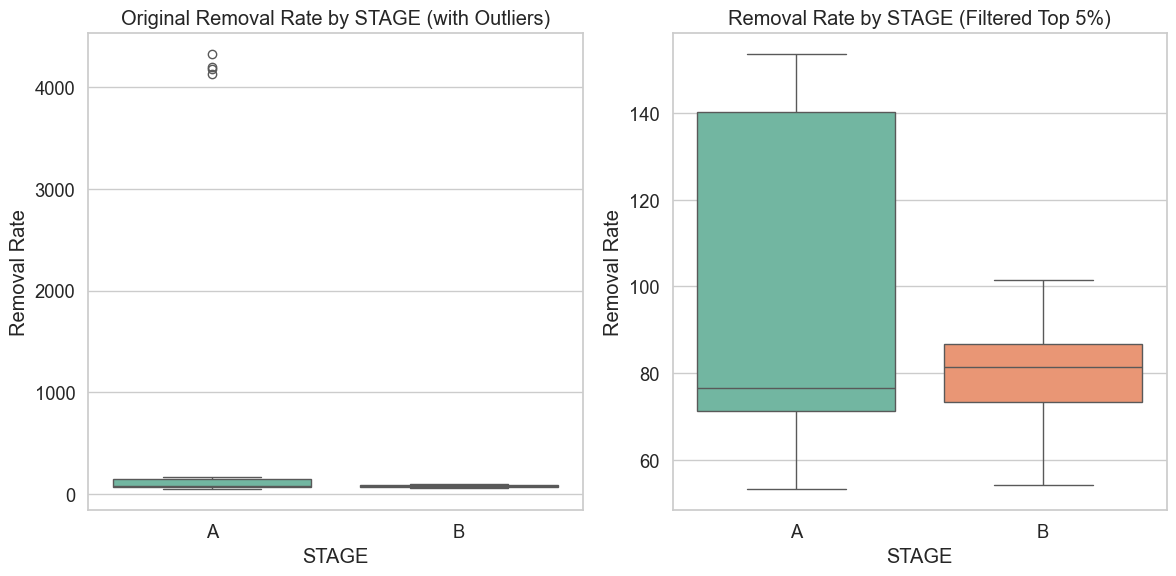

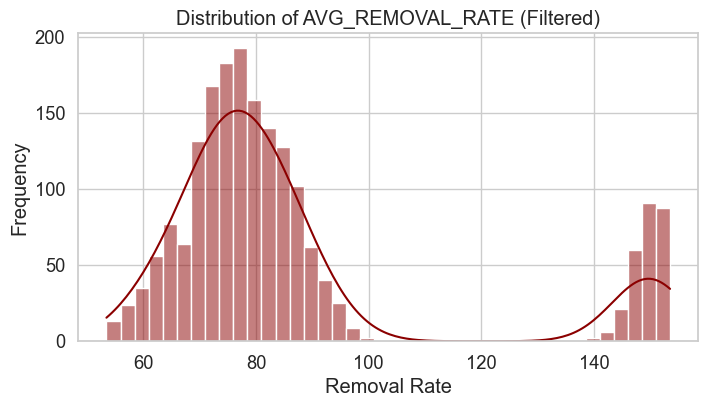

In [6]:
import seaborn as sns
# 檢查整行完全重複的數量
total_duplicates = df_final.duplicated().sum()
print(f"Number of duplicate rows: {total_duplicates}")

# 如果有，可以印出來看看
if total_duplicates > 0:
    print(df_final[df_final.duplicated()])
    
# A. 檢查冗餘欄位 (常數欄位)
constant_cols = df_final.columns[df_final.nunique() <= 1].tolist()
print(f"Number of constant columns: {len(constant_cols)}")
print(f"Constant columns: {constant_cols}")

# B. 檢查特徵中的 NaN (聚合後可能產生的)
null_counts = df_final.isnull().sum().sum()
print(f"Number of missing values after merging: {null_counts}")

# ==========================================
# 4. 視覺化繪圖 (產出圖檔供報告使用)
# ==========================================

# 建立畫布：一列兩個圖
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# A. 原始資料箱型圖 (展示極端值的存在)
sns.boxplot(x='STAGE', y='AVG_REMOVAL_RATE', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Original Removal Rate by STAGE (with Outliers)')
axes[0].set_ylabel('Removal Rate')

# B. 過濾極端值後的箱型圖 (為了看清楚 A/B 階段的差異)
# 使用 95 百分位數過濾掉極端的 5%
q_limit = df['AVG_REMOVAL_RATE'].quantile(0.95)
df_filtered = df[df['AVG_REMOVAL_RATE'] < q_limit]

sns.boxplot(x='STAGE', y='AVG_REMOVAL_RATE', data=df_filtered, ax=axes[1], palette='Set2')
axes[1].set_title('Removal Rate by STAGE (Filtered Top 5%)')
axes[1].set_ylabel('Removal Rate')

plt.tight_layout()
plt.show()

# C. 分佈圖 (Histogram)
plt.figure(figsize=(8, 4))
sns.histplot(df_filtered['AVG_REMOVAL_RATE'], kde=True, color='darkred', bins=40)
plt.title('Distribution of AVG_REMOVAL_RATE (Filtered)')
plt.xlabel('Removal Rate')
plt.ylabel('Frequency')
plt.show()
